**Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



**Load Dataset**

In [ ]:
train_df = pd.read_csv("customer_churn_dataset-training-master.csv")
test_df = pd.read_csv("customer_churn_dataset-testing-master.csv")

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (440833, 12)
Test Shape : (64374, 12)


**Basic Cleaning**

In [ ]:
for df in [train_df, test_df]:
    df.dropna(inplace=True)
    df.drop_duplicates(inplace=True)
    df.drop(columns=['CustomerID'], errors='ignore', inplace=True)

**Split Features and Target**

In [ ]:
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

**Preprocessing**

**One Hot Encoding**

In [ ]:
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


**Scaling**

In [ ]:
scaler = StandardScaler()

num_cols = ['Age', 'Tenure', 'Usage Frequency',
            'Support Calls', 'Payment Delay',
            'Total Spend', 'Last Interaction']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

**Evaluation Function**

In [ ]:
results = []

def evaluate_model(model, name, threshold=0.5):
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]

    preds = (probs > threshold).astype(int)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append([name, threshold, acc, prec, rec, f1])

    print(f"\n===== {name} (Threshold={threshold}) =====")
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 Score :", round(f1,4))


    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix (T={threshold})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

**Train Models**

**Logistic Regression**


===== Logistic Regression (Threshold=0.85) =====
Accuracy : 0.6317
Precision: 0.5677
Recall   : 0.9333
F1 Score : 0.7059


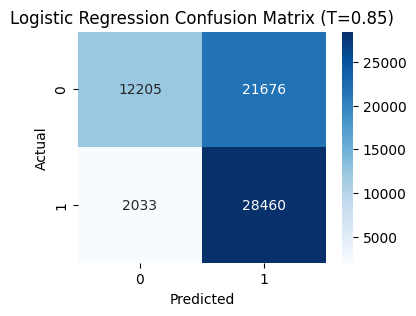

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

evaluate_model(lr, "Logistic Regression", threshold=0.85)

**Decision Tree**


===== Decision Tree (Threshold=0.85) =====
Accuracy : 0.5101
Precision: 0.4916
Recall   : 0.9982
F1 Score : 0.6587


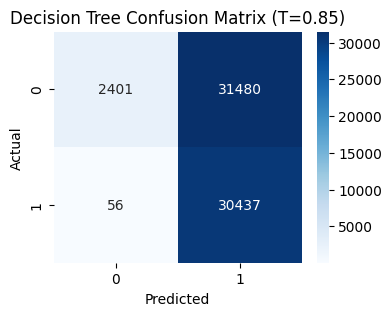

In [ ]:
dt = DecisionTreeClassifier(max_depth=8, random_state=42)
evaluate_model(dt, "Decision Tree",threshold=0.85)

**Random Forest**


===== Random Forest (Threshold=0.85) =====
Accuracy : 0.5245
Precision: 0.499
Recall   : 0.9972
F1 Score : 0.6652


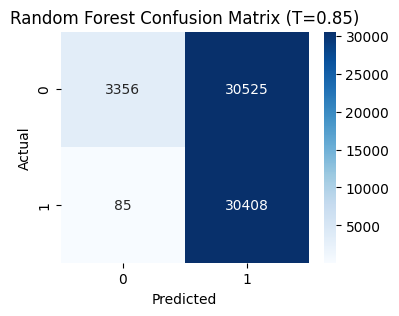

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)
evaluate_model(rf, "Random Forest",threshold=0.85)

**Model Comparison**

,Model,Threshold,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.85,0.631699,0.567656,0.933329,0.705949
2,Random Forest,0.85,0.524497,0.499040,0.997212,0.665194
1,Decision Tree,0.85,0.510113,0.491577,0.998164,0.658738


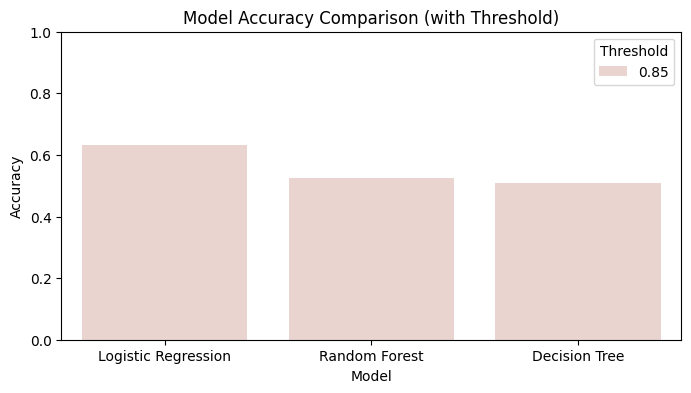

In [ ]:
comparison_df = pd.DataFrame(
    results,
    columns=['Model','Threshold','Accuracy','Precision','Recall','F1']
)
comparison_df = comparison_df.sort_values(by='F1', ascending=False)

display(comparison_df)

plt.figure(figsize=(8,4))
sns.barplot(x='Model', y='Accuracy', hue='Threshold', data=comparison_df)
plt.title("Model Accuracy Comparison (with Threshold)")
plt.ylim(0,1)
plt.show()

**Feature Importance**

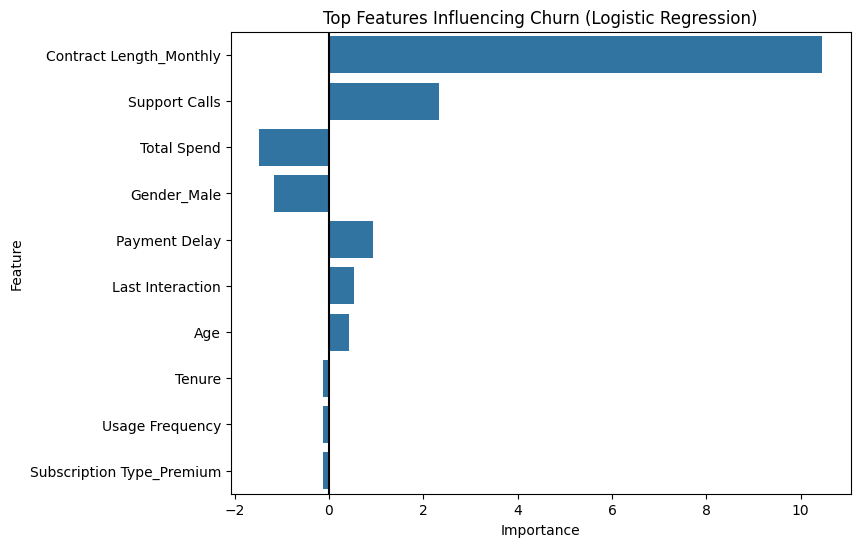

In [ ]:
coefficients = lr.coef_[0]
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})


importance_df['Abs_Importance'] = importance_df['Importance'].abs()
importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False)


plt.figure(figsize=(8,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10)
)
plt.title("Top Features Influencing Churn (Logistic Regression)")
plt.axvline(0, color='black')
plt.show()

**Classification Report**

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.86      0.36      0.51     33881
           1       0.57      0.93      0.71     30493

    accuracy                           0.63     64374
   macro avg       0.71      0.65      0.61     64374
weighted avg       0.72      0.63      0.60     64374



<Axes: xlabel='Model', ylabel='F1'>

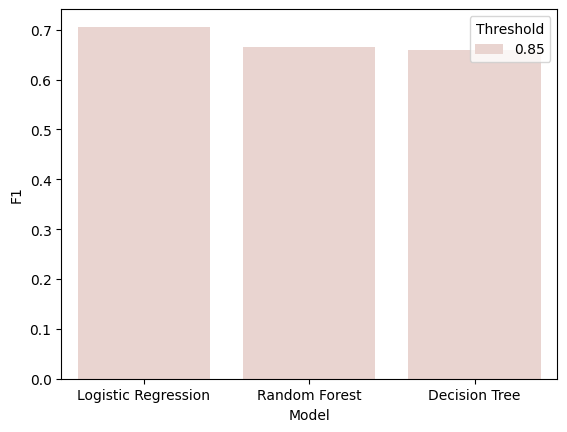

In [ ]:
sns.barplot(x='Model', y='F1', hue='Threshold', data=comparison_df)

**Saving Model**

In [ ]:
best_model = lr
THRESHOLD = 0.85

joblib.dump({
    "model": best_model,
    "scaler": scaler,
    "threshold": THRESHOLD,
    "features": X_train.columns.tolist()
}, "full_pipeline.pkl")


['full_pipeline.pkl']

**Checking data leakage and Overfitting Issue**

In [ ]:
print("Baseline accuracy:",
      max(y_test.value_counts(normalize=True)))

Baseline accuracy: 0.5263149718830584


In [ ]:
corr = train_df.corr(numeric_only=True)['Churn'].abs().sort_values(ascending=False)
corr

,Churn
Churn,1.000000
Support Calls,0.574267
Total Spend,0.429355
Payment Delay,0.312129
Age,0.218394
Last Interaction,0.149616
Tenure,0.051919
Usage Frequency,0.046101


In [ ]:
train_probs = lr.predict_proba(X_train)[:, 1]
test_probs  = lr.predict_proba(X_test)[:, 1]


THRESHOLD = 0.85

train_preds = (train_probs > THRESHOLD).astype(int)
test_preds  = (test_probs > THRESHOLD).astype(int)

from sklearn.metrics import accuracy_score

print("Train accuracy:", accuracy_score(y_train, train_preds))
print("Test accuracy :", accuracy_score(y_test, test_preds))

Train accuracy: 0.8543889735772358
Test accuracy : 0.6316991331904185


## Conclusion

In this project, multiple machine learning models—including Logistic Regression, Decision Tree, and Random Forest—were evaluated for customer churn prediction. Initially, some models showed misleadingly high performance due to issues like data leakage and default decision thresholds. After correcting these issues and ensuring proper train-test separation, the models were re-evaluated under realistic conditions.

Among all models, Logistic Regression was selected as the final model. Although its raw accuracy was moderate, it demonstrated more stable and interpretable behavior compared to tree-based models, which tended to over-predict the churn class. Logistic Regression provided reliable probability estimates, which allowed effective threshold tuning.

Instead of relying on the default threshold of 0.5, threshold optimization was performed to balance precision and recall. A threshold of 0.85 was selected based on the best F1 score, ensuring a more balanced and practical prediction strategy. This approach reduced false positives and improved decision-making quality, making the model more suitable for real-world business scenarios.

Overall, the final solution emphasizes not just model selection, but also proper evaluation techniques, handling of class imbalance, and threshold optimization. These steps ensured that the model delivers meaningful and actionable insights for customer retention, rather than just high but misleading accuracy.

# ==============================
#  MILESTONE 2: AI AGENT
# ==============================

**Load saved pipeline**

In [ ]:
import joblib

data = joblib.load("full_pipeline.pkl")

model = data["model"]
scaler = data["scaler"]
threshold = data["threshold"]
features = data["features"]

In [ ]:
def predict_churn(input_df):
    data = joblib.load("full_pipeline.pkl")

    model = data["model"]
    scaler = data["scaler"]
    threshold = data["threshold"]
    features = data["features"]


    input_df = pd.get_dummies(input_df)


    input_df = input_df.reindex(columns=features, fill_value=0)


    input_df[num_cols] = scaler.transform(input_df[num_cols])


    prob = model.predict_proba(input_df)[0][1]
    prob = round(prob, 4)
    prob = min(prob, 0.99)

    pred = int(prob > threshold)

    return pred, prob

**RAG setup**

In [120]:
pip install -U langchain langchain-community chromadb sentence-transformers

In [ ]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

documents = [
    "Customers with high support calls are likely to churn",
    "Low tenure increases churn risk",
    "High payment delays indicate dissatisfaction",
    "Low usage frequency signals disengagement",
    "High spend customers should be retained with offers"
]

embedding = HuggingFaceEmbeddings()
vector_db = Chroma.from_texts(documents, embedding)

/tmp/ipykernel_5051/2222597277.py:12: LangChainDeprecationWarning: Default values for HuggingFaceEmbeddings.model_name were deprecated in LangChain 0.2.16 and will be removed in 0.4.0. Explicitly pass a model_name to the HuggingFaceEmbeddings constructor instead.
  embedding = HuggingFaceEmbeddings()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Retrieval function**

In [ ]:
def get_insights(query):
    results = vector_db.similarity_search(query, k=3)

    unique = list(set([r.page_content for r in results]))

    return " ".join(unique)

**LLM**

In [ ]:
pip install langchain langchain-community langchain-groq

In [ ]:
from google.colab import userdata

api_key = userdata.get("CAPSTONE_API")

In [ ]:
import os
os.environ["GROQ_API_KEY"] = api_key

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant"
)

**Advice function**

In [119]:
def generate_advice(pred, prob, insights):
    if prob > 0.7:
        risk = "High"
    elif prob > 0.4:
        risk = "Medium"
    else:
        risk = "Low"

    prompt = f"""
    Prediction: {"Churn" if pred==1 else "No Churn"}
    Probability: {prob}
    Risk Level: {risk}

    Insights: {insights}

    IMPORTANT:
    - DO NOT change the risk level
    - If probability is low → risk MUST be Low
    - If prediction is No Churn → explain LOW risk

    Provide:
    - Reason
    - Risk Level (must be {risk})
    - Retention strategy ONLY if risk is Medium or High
    """

    response = llm.invoke(prompt)
    return response.content

**Testin LLM**

In [106]:
print(generate_advice(1, 0.87, "High support calls and low tenure"))

Based on the given information:

- Reason: The high probability of churn (0.87) is due to high support calls and low tenure, indicating a strong likelihood of the customer leaving the service.
- Risk Level: High
- Retention strategy: To address the high risk of churn, a retention strategy can be implemented to improve customer engagement and satisfaction. This can include:
  - Regular check-ins to ensure customer needs are being met
  - Offering personalized support and solutions
  - Providing incentives for long-term commitment (e.g., loyalty programs or exclusive offers)
  - Analyzing and addressing the root causes of high support calls and low tenure to prevent future churn.


In [107]:
response = llm.invoke("Explain customer churn in simple terms")
print(response.content)

Customer churn refers to when a customer stops using or buying from a company. This can happen for various reasons, such as dissatisfaction with the product or service, competition from other companies, or issues with customer support.

Here are some simple examples:

1. You sign up for a streaming service, but after 2 months, you cancel your subscription because you're not enjoying the content.
2. A customer buys a smartphone from a company, but returns it after a week because they're not satisfied with its performance.
3. A customer switches from one bank to another because of better rates or services.

Customer churn is a major concern for businesses because it:

- Can lead to lost revenue and profits
- Requires time and money to acquire new customers
- Can damage a company's reputation if not managed properly

Businesses often try to reduce customer churn by:

- Providing excellent customer support
- Improving their products or services
- Offering competitive pricing and promotions

**LangGraph Agent**

In [116]:
from langgraph.graph import StateGraph
from typing import TypedDict

class State(TypedDict):
    input_data: dict
    prediction: int
    probability: float
    insights: str
    advice: str

**Agent Nodes**

**Prediction Node**

In [115]:
def predict_node(state):
    df = pd.DataFrame([state["input_data"]])

    pred, prob = predict_churn(df)

    return {
        "prediction": pred,
        "probability": prob
    }

**RAG Node**

In [117]:
def create_query(input_data):
    query_parts = []

    if input_data["Support Calls"] > 3:
        query_parts.append("high support calls churn")

    if input_data["Tenure"] < 3:
        query_parts.append("low tenure churn risk")

    if input_data["Usage Frequency"] < 3:
        query_parts.append("low usage churn")

    if input_data["Payment Delay"] > 5:
        query_parts.append("payment delay churn")

    if not query_parts:
        query_parts.append("loyal customer behavior")

    return " ".join(query_parts)

In [118]:
def rag_node(state):
    query = create_query(state["input_data"])

    insights = get_insights(query)

    return {
        "insights": insights
    }

**Advice Node**

In [113]:
def advice_node(state):
    advice = generate_advice(
        state["prediction"],
        state["probability"],
        state["insights"]
    )

    return {
        "advice": advice
    }

**Agent Graph**

In [112]:
builder = StateGraph(State)

builder.add_node("predict", predict_node)
builder.add_node("rag", rag_node)
builder.add_node("advice", advice_node)

builder.set_entry_point("predict")

builder.add_edge("predict", "rag")
builder.add_edge("rag", "advice")

graph = builder.compile()

**Running the Agent**

In [110]:
result = graph.invoke({
    "input_data": {
        "Age": 30,
        "Tenure": 2,
        "Usage Frequency": 1,
        "Support Calls": 5,
        "Payment Delay": 10,
        "Total Spend": 200,
        "Last Interaction": 2,
        "Gender": "Male",
        "Subscription Type": "Basic",
        "Contract Length": "Monthly"
    }
})

In [111]:
print("Prediction:", "Churn" if result["prediction"]==1 else "No Churn")
print("Probability:", result["probability"])

print("\n Key Insights:")
print("-", result["insights"])

print("\n AI Recommendation:")
print(result["advice"])

Prediction: Churn
Probability: 0.99

 Key Insights:
- Customers with high support calls are likely to churn Low tenure increases churn risk

 AI Recommendation:
Based on the provided information:

- Reason: Due to the high probability of churn (0.99), it is likely that customers have experienced issues with the service, leading to a high number of support calls. Additionally, low tenure increases the churn risk, indicating that these customers may be new or have had a recent change in their circumstances.

- Risk Level: High

- Retention Strategy: 
Given the high risk level, it is crucial to implement a retention strategy to prevent customers from churning. Possible actions include:
- Personalized support: Offer customized support to address the customer's specific issues and concerns.
- Proactive outreach: Regularly contact customers to ensure they are satisfied with the service and address any potential problems before they escalate.
- Incentives: Provide incentives for long-term com